<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_9_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("/content/Ders9_customersatisfaction.csv")

In [ ]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.465395,1.895973
1,1,-0.999657,1.603678
2,2,-1.795268,0.058785
3,3,1.748016,5.568288
4,4,1.071275,3.026426


In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


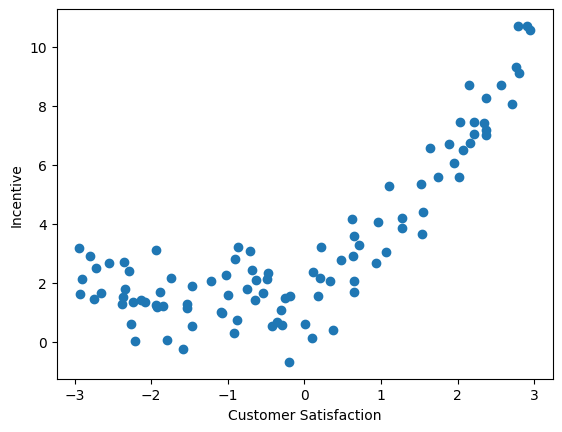

In [ ]:
plt.scatter(df['Customer Satisfaction'],df['Incentive'])
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.show()

**POLİNOM Regresyon**

In [ ]:
#dependent and independent feature
X = df[["Customer Satisfaction"]]
y= df["Incentive"]

In [ ]:
X.head()

,Customer Satisfaction
0,-1.465395
1,-0.999657
2,-1.795268
3,1.748016
4,1.071275


In [ ]:
y.head()

,Incentive
0,1.895973
1,1.603678
2,0.058785
3,5.568288
4,3.026426


In [ ]:
#train - test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=15)

In [ ]:
X_train

,Customer Satisfaction
99,-2.337184
3,1.748016
20,-2.384971
55,-0.484892
6,1.268950
...,...
28,-1.221422
0,-1.465395
5,-0.864827
12,-2.230593


In [ ]:
#scaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
regression = LinearRegression()

In [ ]:
regression.fit(X_train, y_train)

LinearRegression()

In [ ]:
#prediction

In [ ]:
y_pred = regression.predict(X_test)

In [ ]:
y_pred

array([0.77393489, 5.96572198, 5.81999605, 5.35092178, 6.89079454,
       6.6712379 , 0.14789542, 3.9839119 , 3.44277602, 5.22986471,
       3.07536248, 6.44705118, 2.68600204, 2.93815546, 5.2413065 ,
       3.1388729 , 3.63611842, 2.79813925, 2.14900253, 5.65078567])

In [ ]:
score = r2_score(y_test, y_pred)
print(score) #r2 skoru lineer regresyonda istediğimiz seviyede olmadı. Bu nedenle polinom regresyon üzerinden ilerlemeye karar verdik. Daatamızın dağılımıda bunu gösterdi.

0.649886871893218


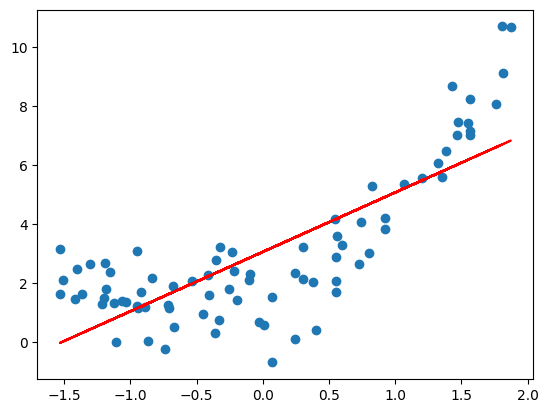

In [ ]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regression.predict(X_train), color='r')
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=2) #polinom regresyon için hazırlık. Degree 2 ve 3 değerleri veriyoruz. ama aşağıda denemelerini yaptık. r2 performansına göre en optimumu verebiliri.

In [ ]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
X_train_poly

array([[ 1.00000000e+00, -1.18289167e+00,  1.39923269e+00],
       [ 1.00000000e+00,  1.20034828e+00,  1.44083599e+00],
       [ 1.00000000e+00, -1.21076979e+00,  1.46596347e+00],
       [ 1.00000000e+00, -1.02293940e-01,  1.04640503e-02],
       [ 1.00000000e+00,  9.20868626e-01,  8.47999027e-01],
       [ 1.00000000e+00,  1.35593477e+00,  1.83855911e+00],
       [ 1.00000000e+00,  3.77447406e-01,  1.42466544e-01],
       [ 1.00000000e+00, -8.38079418e-01,  7.02377110e-01],
       [ 1.00000000e+00,  1.76429579e+00,  3.11273964e+00],
       [ 1.00000000e+00,  8.24065136e-01,  6.79083348e-01],
       [ 1.00000000e+00,  5.43050415e-01,  2.94903753e-01],
       [ 1.00000000e+00,  6.93952449e-02,  4.81570001e-03],
       [ 1.00000000e+00, -2.14777835e-01,  4.61295183e-02],
       [ 1.00000000e+00,  1.38494958e+00,  1.91808534e+00],
       [ 1.00000000e+00,  7.39420932e-01,  5.46743315e-01],
       [ 1.00000000e+00, -1.10603790e+00,  1.22331983e+00],
       [ 1.00000000e+00, -7.11187078e-01

In [ ]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [ ]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9462377252948377


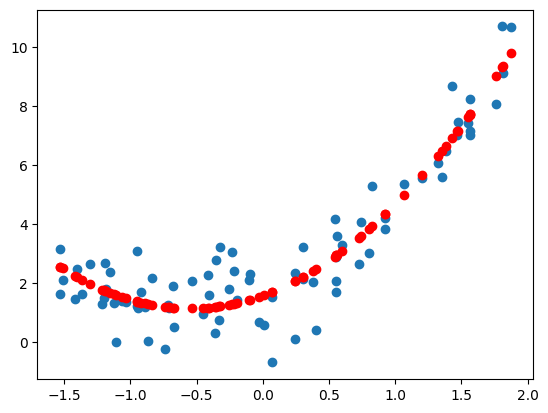

In [ ]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color='r')
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9455563955516928


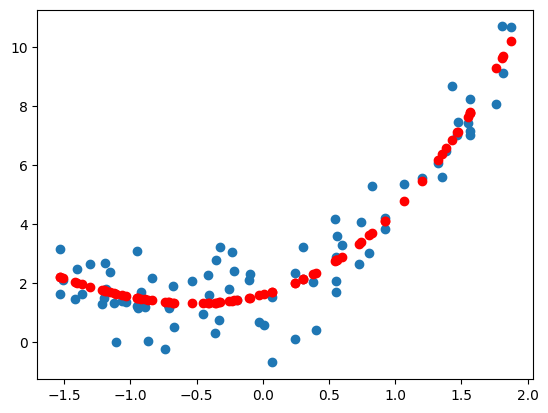

In [ ]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color='r')
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9472398527622318


In [ ]:
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9349641542835465
